In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Explode a list that located in a column into pieces

In [3]:
df_exploded = df.explode('job_skills')
df_exploded.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."


### Count how many values based only for both columns

In [ ]:
df_skill_counts = df_exploded.groupby(['job_skills','job_title_short']).size()
df_skill_counts.head().to_frame()

In [6]:
df_skill_counts = df_skill_counts.reset_index(name='count')
df_skill_counts.head()

,job_skills,job_title_short,count
0,airflow,Business Analyst,318
1,airflow,Cloud Engineer,260
2,airflow,Data Analyst,2002
3,airflow,Data Engineer,25505
4,airflow,Data Scientist,3915


In [7]:
df_skill_counts = df_skill_counts.sort_values('count', ascending=False)
df_skill_counts.head()

,job_skills,job_title_short,count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982


### Visualising the DataFram

<Axes: title={'center': 'Top 10 Skills for Data Analyst'}, xlabel='job_skills'>

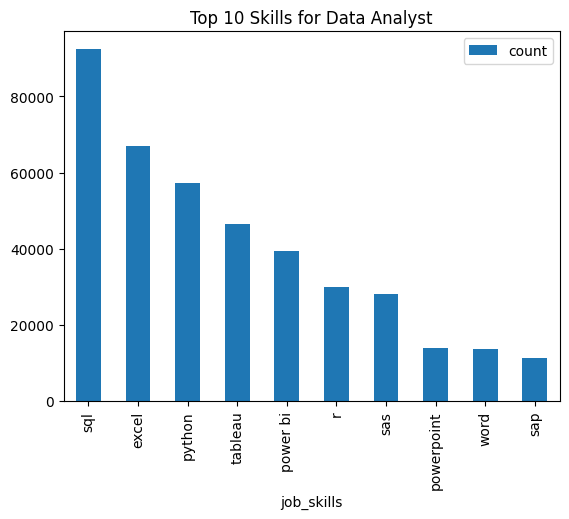

In [8]:
job_title = 'Data Analyst'
top = 10

df_skill_counts[df_skill_counts['job_title_short'] == job_title].head(top).plot(kind='bar', x='job_skills', y='count', title=f'Top {top} Skills for {job_title}')